IMPORT AND DRIVE MOUNT

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, time, random, copy, math, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import binary_erosion, distance_transform_edt
import h5py
import os, time, random, copy, math, json, shutil

Mounted at /content/drive


In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import shutil
import time

SRC = "/content/drive/MyDrive/MRI_Project/BraTS_dataset/BraTS2020_training_data/data"
DST = "/content/BraTS_data"

if os.path.exists(DST):
    print("Dataset already exists in local SSD.")
else:

    files = [f for f in os.listdir(SRC) if f.endswith(".h5")]

    total = len(files)

    print(f"Found {total} files")
    print("Starting copy...\n")

    os.makedirs(DST, exist_ok=True)

    start = time.time()

    for i, f in enumerate(files):

        shutil.copy2(
            os.path.join(SRC, f),
            os.path.join(DST, f)
        )

        if (i + 1) % 1000 == 0:
            elapsed = time.time() - start

            print(
                f"Copied {i+1}/{total} files "
                f"({100*(i+1)/total:.1f}%) "
                f"| Elapsed: {elapsed/60:.1f} min"
            )

    print("\nCopy complete!")

In [ ]:
import os

path = "/content/drive/MyDrive/MRI_Project/BraTS_dataset/BraTS2020_training_data/data/"

files = os.listdir(path)

print(len(files))
print(files[:10])

40627
['volume_330_slice_49.h5', 'volume_330_slice_5.h5', 'volume_330_slice_50.h5', 'volume_330_slice_51.h5', 'volume_330_slice_52.h5', 'volume_330_slice_53.h5', 'volume_330_slice_54.h5', 'volume_330_slice_55.h5', 'volume_330_slice_56.h5', 'volume_330_slice_57.h5']


CONFIGURATION

In [ ]:
CFG = {
    # ── Paths ────────────────────────────────────────────────────────────────
    "DATA_ROOT": "/content/drive/MyDrive/MRI_Project/BraTS_dataset/BraTS2020_training_data/data",
    "SAVE_DIR": "/content/drive/MyDrive/MRI_Project/UniMatch_Checkpoints/",

    # ── Data ─────────────────────────────────────────────────────────────────
    "LABELED_RATIO"  : 0.20,
    "SKIP_EMPTY"     : 0.80,

    # ── Model ────────────────────────────────────────────────────────────────
    "IN_CHANNELS"    : 4,
    "NUM_CLASSES"    : 3,       # WT, TC, ET
    "BASE_CHANNELS"  : 32,
    "DROPOUT"        : 0.10,

    # ── Training ─────────────────────────────────────────────────────────────
    "EPOCHS"         : 30,
    "BATCH_SIZE"     : 4,
    "LR"             : 1e-4,
    "WEIGHT_DECAY"   : 1e-4,
    "NUM_WORKERS"    : 2,
    "SEED"           : 42,

    # ── UniMatch hyper-parameters ─────────────────────────────────────────────
    "CONF_THR"       : 0.40,
    "LAMBDA_U"       : 0.15,
    "EMA_ALPHA"      : 0.99,

    # ── Checkpointing ─────────────────────────────────────────────────────────
    "SAVE_EVERY"     : 2,
    "VAL_EVERY"      : 2,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"Config : {json.dumps(CFG, indent=2)}")

os.makedirs(CFG["SAVE_DIR"], exist_ok=True)

Device : cuda
Config : {
  "DATA_ROOT": "/content/drive/MyDrive/MRI_Project/BraTS_dataset/BraTS2020_training_data/data",
  "SAVE_DIR": "/content/drive/MyDrive/MRI_Project/UniMatch_Checkpoints/",
  "LABELED_RATIO": 0.2,
  "SKIP_EMPTY": 0.8,
  "IN_CHANNELS": 4,
  "NUM_CLASSES": 3,
  "BASE_CHANNELS": 32,
  "DROPOUT": 0.1,
  "EPOCHS": 30,
  "BATCH_SIZE": 4,
  "LR": 0.0001,
  "WEIGHT_DECAY": 0.0001,
  "NUM_WORKERS": 2,
  "SEED": 42,
  "CONF_THR": 0.4,
  "LAMBDA_U": 0.15,
  "EMA_ALPHA": 0.99,
  "SAVE_EVERY": 2,
  "VAL_EVERY": 2
}


SEEDING

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CFG["SEED"])

DATA UTILITIES

In [ ]:
def load_h5(path):
    with h5py.File(path, 'r') as f:
        image = f['image'][:].astype(np.float32)   # (240, 240, 4)
        mask  = f['mask'][:].astype(np.float32)    # (240, 240, 3)
    image = np.transpose(image, (2, 0, 1))         # (4, 240, 240)
    mask  = np.transpose(mask,  (2, 0, 1))         # (3, 240, 240)
    return image, mask

def normalize_image(image):
    out = np.zeros_like(image, dtype=np.float32)
    for c in range(image.shape[0]):
        ch = image[c]
        m  = ch > 0
        if m.sum() == 0:
            out[c] = ch
            continue
        mu, sigma = ch[m].mean(), ch[m].std() + 1e-8
        out[c] = (ch - mu) / sigma
    return out

def split_patients(root, labeled_ratio=0.10, seed=42):
    all_files = sorted([f for f in os.listdir(root) if f.endswith(".h5")])

    if len(all_files) == 0:
        raise ValueError(f"No .h5 files found in {root} — check DATA_ROOT")

    volumes = sorted(set([f.split("_slice_")[0] for f in all_files]))

    rng = random.Random(seed)
    rng.shuffle(volumes)

    val_n     = max(1, int(len(volumes) * 0.15))
    val       = volumes[:val_n]
    train     = volumes[val_n:]
    lab_n     = max(1, int(len(train) * labeled_ratio))
    labeled   = train[:lab_n]
    unlabeled = train[lab_n:]

    print(f"Volumes  total={len(volumes)}  labeled={len(labeled)}"
          f"  unlabeled={len(unlabeled)}  val={len(val)}")

    def get_files(vol_list):
        vol_set = set(vol_list)
        return [os.path.join(root, f) for f in all_files
                if f.split("_slice_")[0] in vol_set]

    return get_files(labeled), get_files(unlabeled), get_files(val)

AUGMENTATION

In [ ]:
def weak_aug(img, lbl):
    if random.random() > 0.5:
        img = img[:, ::-1].copy()
        lbl = lbl[:, ::-1].copy()
    return img, lbl

def strong_aug(img, lbl):
    if random.random() > 0.5:
        img = img[:, ::-1].copy()
        lbl = lbl[:, ::-1].copy()
    if random.random() > 0.5:
        img = img[:, :, ::-1].copy()
        lbl = lbl[:, :, ::-1].copy()
    k = random.randint(0, 3)
    if k:
        img = np.rot90(img, k, (1, 2)).copy()
        lbl = np.rot90(lbl, k, (1, 2)).copy()
    if random.random() > 0.5:
        img = img + np.random.normal(0, 0.05, img.shape).astype(np.float32)
    for c in range(img.shape[0]):
        if random.random() > 0.5:
            img[c] = img[c] * random.uniform(0.8, 1.2)
    return img, lbl

def cutmix(img1, lbl1, img2, lbl2, alpha=1.0):
    _, H, W = img1.shape
    lam = np.random.beta(alpha, alpha)
    cw  = int(W * math.sqrt(1 - lam))
    ch  = int(H * math.sqrt(1 - lam))
    cx, cy = random.randint(0, W), random.randint(0, H)
    x1, y1 = max(cx - cw//2, 0), max(cy - ch//2, 0)
    x2, y2 = min(cx + cw//2, W), min(cy + ch//2, H)
    out_img = img1.copy()
    out_lbl = lbl1.copy()
    out_img[:, y1:y2, x1:x2] = img2[:, y1:y2, x1:x2]
    out_lbl[:, y1:y2, x1:x2] = lbl2[:, y1:y2, x1:x2]
    return out_img, out_lbl

DATASETS

In [ ]:
class LabeledDS(Dataset):
    def __init__(self, file_paths, skip_empty=0.8):
        self.files = file_paths

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        image, mask = load_h5(self.files[i])
        image = normalize_image(image)
        image, mask = weak_aug(image, mask)
        return {
            "image": torch.from_numpy(image.copy()),
            "label": torch.from_numpy(mask.copy())
        }


class UnlabeledDS(Dataset):
    def __init__(self, file_paths):
        self.files = file_paths

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        image, mask = load_h5(self.files[i])
        image = normalize_image(image)
        dummy = np.zeros_like(mask)
        iw,  _ = weak_aug(image.copy(),  dummy.copy())
        is1, _ = strong_aug(image.copy(), dummy.copy())
        is2, _ = strong_aug(image.copy(), dummy.copy())
        is1, _ = cutmix(is1, dummy, is2, dummy)
        return {
            "image_weak":    torch.from_numpy(iw.copy()),
            "image_strong1": torch.from_numpy(is1.copy()),
            "image_strong2": torch.from_numpy(is2.copy())
        }


class ValDS(Dataset):
    def __init__(self, file_paths):
        self.files = file_paths

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        image, mask = load_h5(self.files[i])
        image = normalize_image(image)
        return {
            "image": torch.from_numpy(image.copy()),
            "label": torch.from_numpy(mask.copy())
        }

def inf_loader(dl):
    while True:
        for b in dl: yield b

U-NET MODEL

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, ic, oc, drop=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(True),
            nn.Dropout2d(drop),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(True))
    def forward(self, x): return self.net(x)

class Down(nn.Module):
    def __init__(self, ic, oc, drop=0.0):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(ic, oc, drop))
    def forward(self, x): return self.net(x)

class Up(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.up   = nn.ConvTranspose2d(ic, ic//2, 2, stride=2)
        self.conv = DoubleConv(ic, oc)
    def forward(self, x, skip):
        x  = self.up(x)
        dh = skip.size(2) - x.size(2)
        dw = skip.size(3) - x.size(3)
        x  = F.pad(x, [dw//2, dw-dw//2, dh//2, dh-dh//2])
        return self.conv(torch.cat([skip, x], 1))

class UNet2D(nn.Module):
    def __init__(self, ic=4, nc=3, b=32, drop=0.1):
        super().__init__()
        self.inc  = DoubleConv(ic, b)
        self.d1   = Down(b,    b*2)
        self.d2   = Down(b*2,  b*4)
        self.d3   = Down(b*4,  b*8)
        self.d4   = Down(b*8,  b*16, drop)
        self.u1   = Up(b*16,  b*8)
        self.u2   = Up(b*8,   b*4)
        self.u3   = Up(b*4,   b*2)
        self.u4   = Up(b*2,   b)
        self.outc = nn.Conv2d(b, nc, 1)

    def forward(self, x):
        x1   = self.inc(x)
        x2   = self.d1(x1)
        x3   = self.d2(x2)
        x4   = self.d3(x3)
        x5   = self.d4(x4)
        d    = self.u1(x5, x4)
        d    = self.u2(d,  x3)
        d    = self.u3(d,  x2)
        feat = self.u4(d,  x1)
        return self.outc(feat), feat

LOSS FUNCTIONS

In [ ]:
def sup_loss(logits, labels):
    weights = torch.tensor([2.0, 3.0, 1.0]).to(logits.device)
    bce  = F.binary_cross_entropy_with_logits(
        logits, labels,
        pos_weight=weights.view(1, 3, 1, 1)
    )
    sig   = torch.sigmoid(logits)
    inter = (sig * labels).sum((2, 3))
    union = sig.sum((2, 3)) + labels.sum((2, 3))
    dice  = (1 - (2 * inter + 1e-5) / (union + 1e-5)).mean()
    return 0.5 * bce + 0.5 * dice

def consist_loss(pred, pseudo, mask):
    loss = F.binary_cross_entropy_with_logits(pred, pseudo, reduction='none')
    return (loss * mask.unsqueeze(1)).sum() / (mask.sum() + 1e-8)

EMA TEACHER

In [ ]:
def ema_update(teacher, student, alpha=0.999):
    for tp, sp in zip(teacher.parameters(), student.parameters()):
        tp.data.mul_(alpha).add_(sp.data, alpha=1-alpha)

METRICS AND VALIDATION

In [ ]:
def dice_coef(p, g, smooth=1e-5):
    return float((2*(p & g).sum() + smooth) / (p.sum() + g.sum() + smooth))

def brats_metrics(pred, gt):
    names = ("WT", "TC", "ET")
    res = {}
    for i, n in enumerate(names):
        p = pred[i] > 0.5
        g = gt[i]   > 0.5
        res[f"Dice_{n}"] = dice_coef(p, g)
    res["Dice_mean"] = float(np.nanmean([res[f"Dice_{n}"] for n in names]))
    return res

@torch.no_grad()
def validate(teacher, val_loader, device):
    teacher.eval()
    all_m = []
    for batch in val_loader:
        imgs   = batch["image"].to(device)
        labels = batch["label"].numpy()
        preds  = torch.sigmoid(teacher(imgs)[0]).cpu().numpy()
        for p, g in zip(preds, labels):
            all_m.append(brats_metrics(p, g))
    keys = all_m[0].keys()
    return {k: float(np.nanmean([m[k] for m in all_m])) for k in keys}

CHECKPOINT HELPER

In [ ]:
def save_checkpoint(path, epoch, student, teacher, optimizer, scheduler,
                    best_dice, metrics_history):
    torch.save({
        "epoch"           : epoch,
        "student_state"   : student.state_dict(),
        "teacher_state"   : teacher.state_dict(),
        "optimizer_state" : optimizer.state_dict(),
        "scheduler_state" : scheduler.state_dict(),
        "best_dice"       : best_dice,
        "metrics_history" : metrics_history,
        "cfg"             : CFG,
    }, path)
    print(f"  [CKPT] Saved → {path}")

def load_checkpoint(path, student, teacher, optimizer, scheduler):
    ckpt = torch.load(path, map_location=DEVICE)
    student.load_state_dict(ckpt["student_state"])
    teacher.load_state_dict(ckpt["teacher_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    print(f"  [CKPT] Resumed from epoch {ckpt['epoch']} — "
          f"best Dice = {ckpt['best_dice']:.4f}")
    return ckpt["epoch"], ckpt["best_dice"], ckpt.get("metrics_history", [])
def permanent_save(src_dir):
    dst = "content/drive/MyDrive/MRI_Project/backup_checkpoints"
    os.makedirs(dst, exist_ok=True)
    for f in os.listdir(src_dir):
        if f.endswith(".pth"):
            shutil.copy2(
                os.path.join(src_dir, f),
                os.path.join(dst, f)
            )
    print(f"  [BACKUP] Checkpoints backed up → {dst}")

BUILD EVERYTHING

In [ ]:
labeled_dirs, unlabeled_dirs, val_dirs = split_patients(
    CFG["DATA_ROOT"], CFG["LABELED_RATIO"], CFG["SEED"])

labeled_dirs   = labeled_dirs[:3000]
unlabeled_dirs = unlabeled_dirs[:12000]

print(len(labeled_dirs))
print(len(unlabeled_dirs))
print(len(val_dirs))

labeled_ds   = LabeledDS(labeled_dirs, CFG["SKIP_EMPTY"])
unlabeled_ds = UnlabeledDS(unlabeled_dirs)
val_ds       = ValDS(val_dirs)

print(f"Labeled slices   : {len(labeled_ds)}")
print(f"Unlabeled slices : {len(unlabeled_ds)}")
print(f"Val slices       : {len(val_ds)}")

labeled_loader   = DataLoader(labeled_ds,   CFG["BATCH_SIZE"], shuffle=True,
                               num_workers=CFG["NUM_WORKERS"], pin_memory=True,
                               drop_last=True)
unlabeled_loader = DataLoader(unlabeled_ds, CFG["BATCH_SIZE"], shuffle=True,
                               num_workers=CFG["NUM_WORKERS"], pin_memory=True,
                               drop_last=True)
val_loader       = DataLoader(val_ds, batch_size=4, shuffle=False,
                               num_workers=CFG["NUM_WORKERS"], pin_memory=True)

student = UNet2D(CFG["IN_CHANNELS"], CFG["NUM_CLASSES"],
                 CFG["BASE_CHANNELS"], CFG["DROPOUT"]).to(DEVICE)
teacher = copy.deepcopy(student)
for p in teacher.parameters(): p.requires_grad_(False)

optimizer = optim.AdamW(student.parameters(),
                        lr=CFG["LR"], weight_decay=CFG["WEIGHT_DECAY"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["EPOCHS"], eta_min=CFG["LR"]*0.01)

total_params = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f"\nModel params : {total_params:,}")
print(f"Iters/epoch  : {len(labeled_loader)}")

Volumes  total=263  labeled=44  unlabeled=180  val=39
3000
12000
5904
Labeled slices   : 3000
Unlabeled slices : 12000
Val slices       : 5904

Model params : 7,763,395
Iters/epoch  : 750


AUTO RESUME

In [ ]:
start_epoch     = 0
best_dice       = 0.0
metrics_history = []

RESUME_PATH = os.path.join(
    CFG["SAVE_DIR"],
    "latest_unimatch.pth"
)

print("Resume Path:", RESUME_PATH)
print("Exists:", os.path.exists(RESUME_PATH))

if os.path.exists(RESUME_PATH):
    start_epoch, best_dice, metrics_history = load_checkpoint(
        RESUME_PATH,
        student,
        teacher,
        optimizer,
        scheduler
    )
else:
    print("No checkpoint found — starting fresh.")

Resume Path: /content/drive/MyDrive/MRI_Project/UniMatch_Checkpoints/latest_unimatch.pth
Exists: False
No checkpoint found — starting fresh.


In [ ]:
ckpt = torch.load(
    "/content/drive/MyDrive/MRI_Project/UniMatch_Checkpoints/latest_unimatch.pth",
    map_location="cpu"
)

print("Epoch:", ckpt["epoch"])
print("Best Dice:", ckpt["best_dice"])

TRAINING LOOP

In [ ]:
unl_iter = inf_loader(unlabeled_loader)
iters    = len(labeled_loader)

print("=" * 70)
print(f"  UniMatch Training   |   {CFG['EPOCHS']} epochs  |  {DEVICE}")
print("=" * 70)

train_start = time.time()

for epoch in range(start_epoch + 1, CFG["EPOCHS"] + 1):
    student.train(); teacher.train()
    ep_sup = ep_u = ep_tot = ep_conf = 0.0
    ep_start = time.time()

    for lbatch in labeled_loader:
        ubatch = next(unl_iter)

        imgs   = lbatch["image"].to(DEVICE)
        labels = lbatch["label"].to(DEVICE)
        iw     = ubatch["image_weak"].to(DEVICE)
        is1    = ubatch["image_strong1"].to(DEVICE)
        is2    = ubatch["image_strong2"].to(DEVICE)

        # ── Supervised loss ──────────────────────────────────────────────────
        logits, _ = student(imgs)
        l_sup = sup_loss(logits, labels)

        # ── Pseudo-label from teacher on weak view ───────────────────────────
        with torch.no_grad():
            lw, _  = teacher(iw)
            probs  = torch.sigmoid(lw)
            conf   = probs.max(1).values
            pseudo = (probs > 0.5).float()
            mask   = (conf >= CFG["CONF_THR"]).float()

        # ── Consistency on two strong views ──────────────────────────────────
        ls1, _ = student(is1)
        ls2, _ = student(is2)
        l_u = 0.5 * (consist_loss(ls1, pseudo, mask) +
                     consist_loss(ls2, pseudo, mask))

        loss = l_sup + CFG["LAMBDA_U"] * l_u

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        optimizer.step()
        ema_update(teacher, student, CFG["EMA_ALPHA"])

        ep_sup  += l_sup.item()
        ep_u    += l_u.item()
        ep_tot  += loss.item()
        ep_conf += mask.mean().item()

    scheduler.step()

    ep_dur  = time.time() - ep_start
    eta_sec = (CFG["EPOCHS"] - epoch) * ep_dur
    h, m    = divmod(int(eta_sec), 3600); m //= 60

    print(f"Ep {epoch:4d}/{CFG['EPOCHS']} | "
          f"L_sup={ep_sup/iters:.4f}  L_u={ep_u/iters:.4f}  "
          f"L_tot={ep_tot/iters:.4f}  "
          f"conf%={ep_conf/iters*100:.1f}  "
          f"[{ep_dur:.0f}s/ep  ETA {h}h{m:02d}m]")
    # ── Validation ───────────────────────────────────────────────────────────
    if epoch % CFG["VAL_EVERY"] == 0 or epoch == CFG["EPOCHS"]:
        m = validate(teacher, val_loader, DEVICE)
        metrics_history.append({"epoch": epoch, **m})
        print(f"  >> VAL  Dice WT={m['Dice_WT']:.4f}  TC={m['Dice_TC']:.4f}  "
              f"ET={m['Dice_ET']:.4f}  Mean={m['Dice_mean']:.4f}")

        if m["Dice_mean"] > best_dice:
            best_dice = m["Dice_mean"]
            save_checkpoint(
                os.path.join(CFG["SAVE_DIR"], "best_unimatch.pth"),
                epoch, student, teacher, optimizer, scheduler,
                best_dice, metrics_history)
            permanent_save(CFG["SAVE_DIR"])

    # ── Periodic checkpoint ──────────────────────────────────────────────────
    if epoch % CFG["SAVE_EVERY"] == 0:
        save_checkpoint(
            os.path.join(CFG["SAVE_DIR"], "latest_unimatch.pth"),
            epoch, student, teacher, optimizer, scheduler,
            best_dice, metrics_history)
        permanent_save(CFG["SAVE_DIR"])


total_time = time.time() - train_start
th, tm = divmod(int(total_time), 3600); tm //= 60
print(f"\n{'='*70}")
print(f"  Training complete in {th}h {tm}m")
print(f"  Best Dice_mean = {best_dice:.4f}")
print(f"{'='*70}")

  UniMatch Training   |   30 epochs  |  cuda

  Training complete in 0h 0m
  Best Dice_mean = 0.8414


FINAL EVALUATION

In [ ]:
best_path = os.path.join(CFG["SAVE_DIR"], "best_unimatch.pth")
ckpt = torch.load(best_path, map_location=DEVICE)
teacher.load_state_dict(ckpt["teacher_state"])

final = validate(teacher, val_loader, DEVICE)
print("\n=== Final Evaluation (best model) ===")
for k, v in final.items():
    print(f"  {k:12s} : {v:.4f}")


=== Final Evaluation (best model) ===
  Dice_WT      : 0.8270
  Dice_TC      : 0.7192
  Dice_ET      : 0.8854
  Dice_mean    : 0.8105


SAMPLE SELCTION CELL AND VISUALIZATION

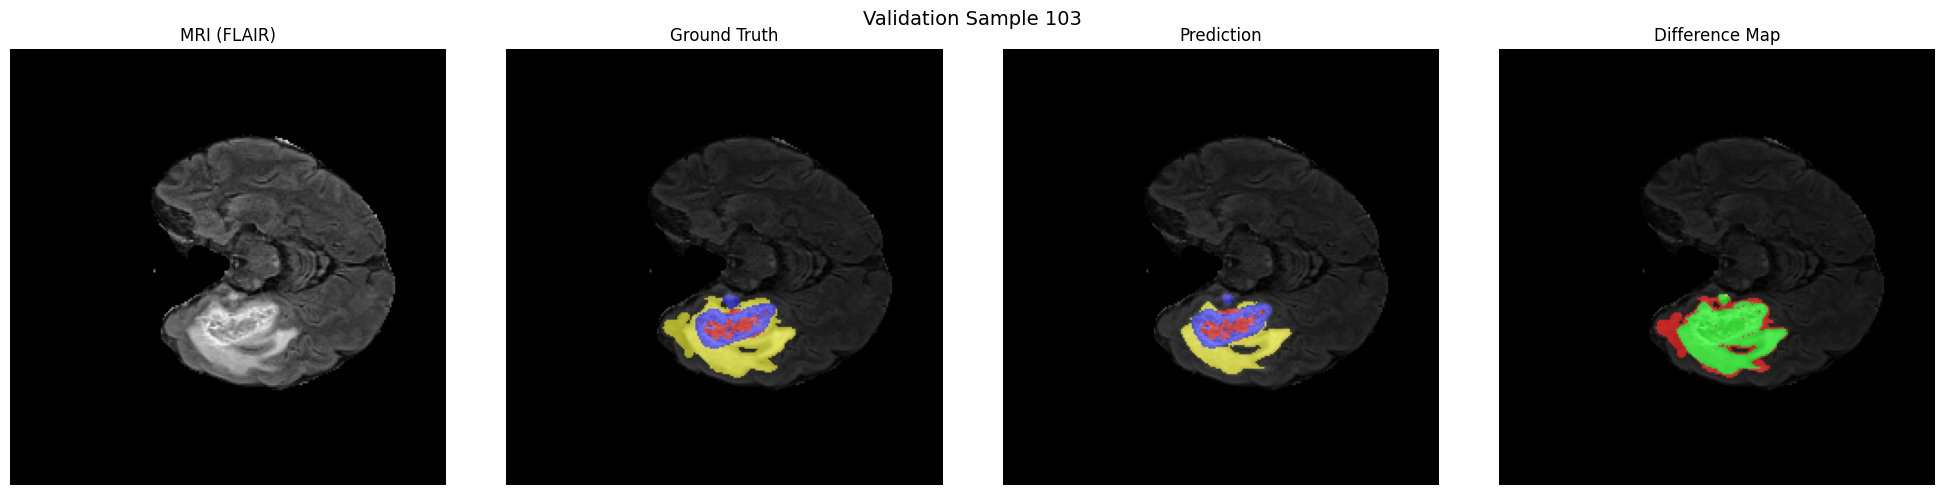

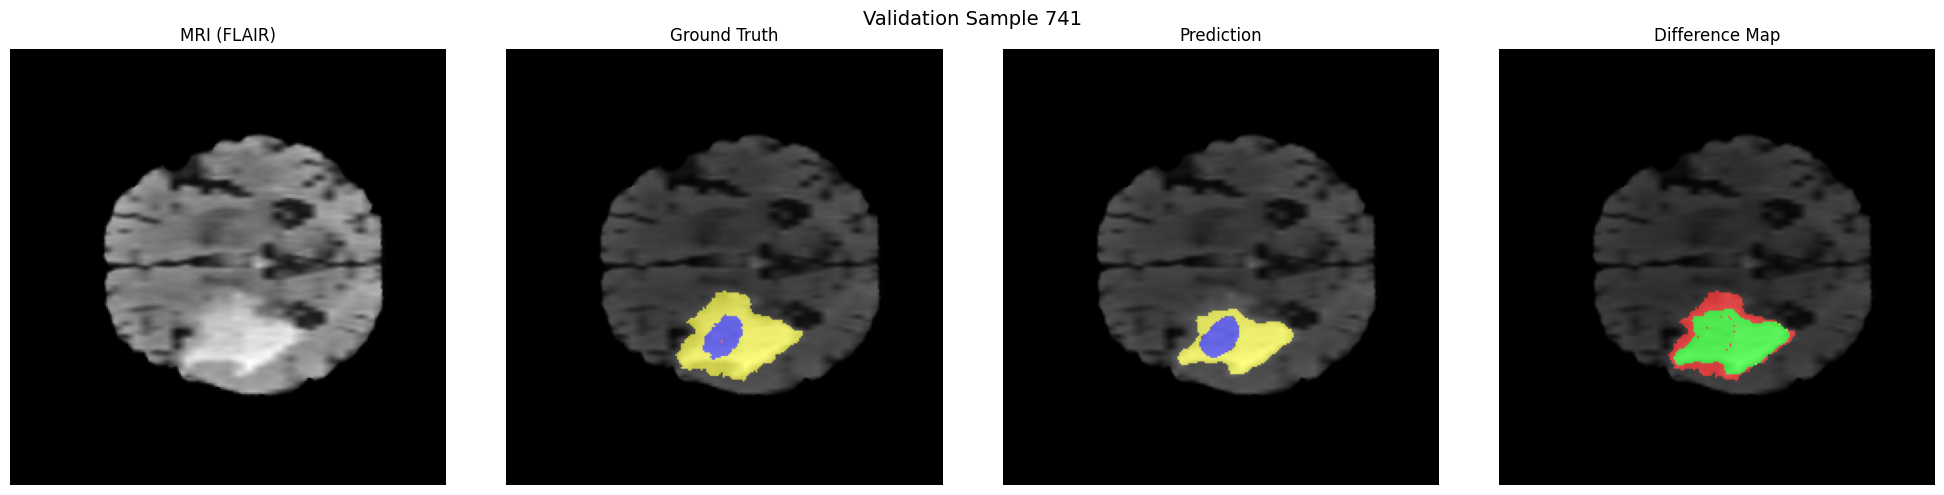

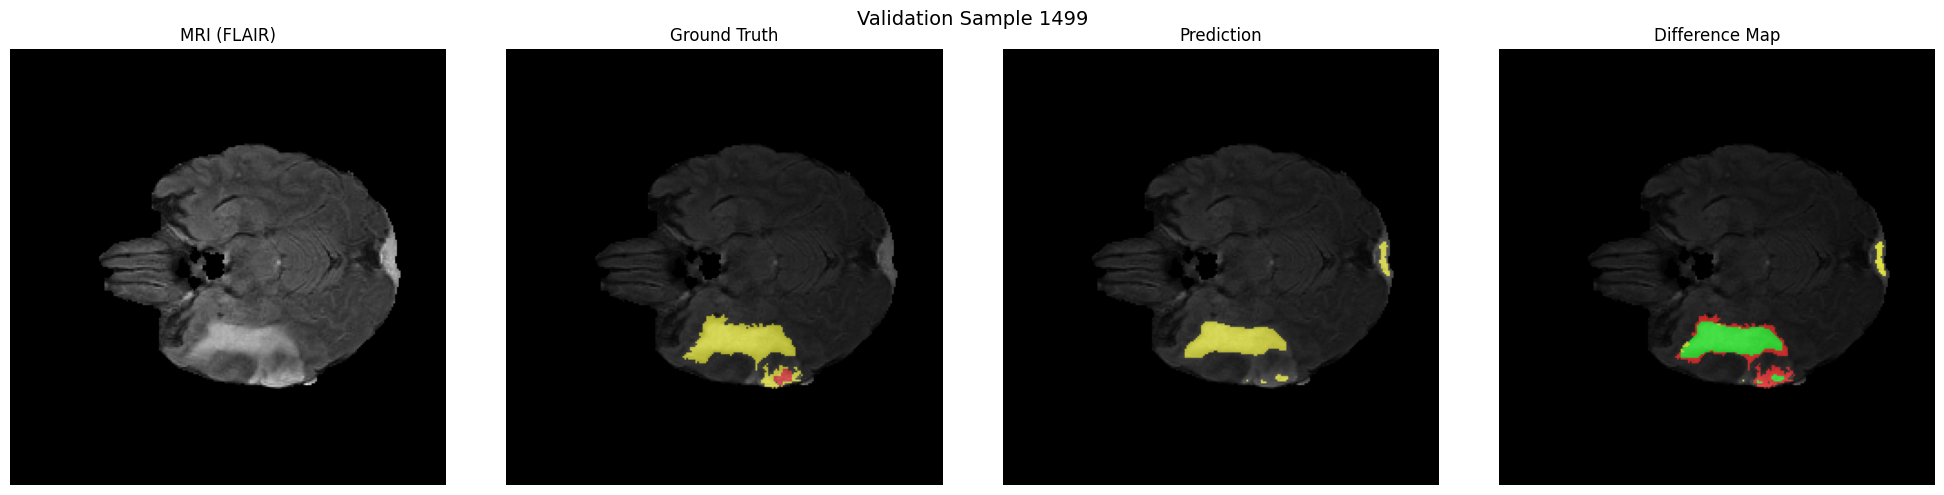

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

samples_to_show = [103, 741, 1499]   # or any slices you want

for idx in samples_to_show:

    sample = val_ds[idx]

    img = sample["image"].unsqueeze(0).to(DEVICE)
    flair = sample["image"][0].numpy()

    gt = sample["label"].numpy()

    with torch.no_grad():
        pred = torch.sigmoid(
            teacher(img)[0]
        ).cpu().numpy()[0]

    pred_bin = (pred > 0.5).astype(np.uint8)

    # =========================
    # Ground Truth Overlay
    # =========================

    gt_overlay = np.zeros((*gt[0].shape, 3))

    gt_overlay[gt[0] == 1] = [1, 0, 0]      # WT = Red
    gt_overlay[gt[1] == 1] = [1, 1, 0]      # TC = Yellow
    gt_overlay[gt[2] == 1] = [0, 0, 1]      # ET = Blue

    # =========================
    # Prediction Overlay
    # =========================

    pred_overlay = np.zeros((*gt[0].shape, 3))

    pred_overlay[pred_bin[0] == 1] = [1, 0, 0]
    pred_overlay[pred_bin[1] == 1] = [1, 1, 0]
    pred_overlay[pred_bin[2] == 1] = [0, 0, 1]

    # =========================
    # Difference Map
    # =========================

    diff = np.zeros((*gt[0].shape, 3))

    gt_union = (gt.sum(0) > 0)
    pred_union = (pred_bin.sum(0) > 0)

    diff[np.logical_and(gt_union, pred_union)] = [0, 1, 0]   # Green = Correct
    diff[np.logical_and(gt_union, ~pred_union)] = [1, 0, 0]  # Red = Missed
    diff[np.logical_and(~gt_union, pred_union)] = [1, 1, 0]  # Yellow = Extra

    # =========================
    # Plot
    # =========================

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # MRI
    axes[0].imshow(flair, cmap="gray")
    axes[0].set_title("MRI (FLAIR)")
    axes[0].axis("off")

    # GT
    axes[1].imshow(flair, cmap="gray")
    axes[1].imshow(gt_overlay, alpha=0.5)
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # Prediction
    axes[2].imshow(flair, cmap="gray")
    axes[2].imshow(pred_overlay, alpha=0.5)
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    # Difference
    axes[3].imshow(flair, cmap="gray")
    axes[3].imshow(diff, alpha=0.6)
    axes[3].set_title("Difference Map")
    axes[3].axis("off")

    plt.suptitle(f"Validation Sample {idx}", fontsize=14)

    plt.tight_layout()
    plt.show()

In [ ]:
sample = val_ds[103]
img = sample["image"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred = torch.sigmoid(
        teacher(img)[0]
    ).cpu().numpy()[0]

print(pred.min())
print(pred.max())
print(pred.mean())

6.032984e-10
0.99998164
0.008896576
